# Implementacja perceptronu w Pythonie (NumPy)

##  Cel ćwiczenia

Celem zadania jest zrozumienie mechanizmu działania perceptronu — podstawowego modelu liniowego stosowanego w najprostszych sztucznych sieciach neuronowych.

Model należy:
- zaimplementować w Pythonie przy użyciu **NumPy**,
- przetestować na zadaniu klasyfikacji binarnej dla zbioru **Iris**,
- użyć tylko **2 klas i 2 cech**, aby uprościć analizę.

---

## Perceptron — definicja

Perceptron to liniowy klasyfikator, który podejmuje decyzję na podstawie liniowej kombinacji cech wejściowych oraz funkcji aktywacji.

Model składa się z:

- wektora wejściowego  
  $$
  \mathbf{x} = [x_1, x_2, \dots, x_n]
  $$

- wektora wag  
  $$
  \mathbf{w} = [w_1, w_2, \dots, w_n]
  $$

- biasu  
  $$
  b
  $$

- funkcji aktywacji (sigmoid)

---

## Model matematyczny

Najpierw obliczana jest kombinacja liniowa:

$$
z = \mathbf{w}^T \mathbf{x} + b
$$

Następnie stosowana jest funkcja aktywacji:

$$
y = f(z)
$$

gdzie funkcja sigmoid ma postać:

$$
f(z) = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

---

## Algorytm uczenia

Uczenie polega na iteracyjnej aktualizacji wag i biasu na podstawie błędu predykcji.
W bardziej skomplikowanych sieciach, proces uczenia jest zwykle usprawniony przez używanie paczek danych (batch) i wydajniejsze metody optymalizacji (np. Adam).

Reguła aktualizacji:

$$
w_i \leftarrow w_i + \eta (y_{true} - y_{pred}) x_i
$$

$$
b \leftarrow b + \eta (y_{true} - y_{pred})
$$

gdzie:

- $\eta$ — współczynnik uczenia (np. 0.1),
- $y_{true}$ — rzeczywista etykieta,
- $y_{pred}$ — przewidywana wartość modelu.

Proces ten powtarzamy dla wszystkich danych przez określoną liczbę epok lub do momentu zbieżności. 

---

## Predykcja

Model zwraca wartość ciągłą z przedziału:

$$
(0, 1)
$$

Aby uzyskać klasy binarne, stosujemy próg decyzyjny:

- jeśli $y \geq 0.5$ → klasa **1**
- jeśli $y < 0.5$ → klasa **0**

Ponieważ sigmoid zwraca wartości w zakresie $(0,1)$, wynik można interpretować jako prawdopodobieństwo przynależności do klasy pozytywnej.

---

## Dane

Ze zbioru **Iris** wybieramy:

- tylko **2 klasy** (problem binarny),
- tylko **2 cechy** (łatwiejsza wizualizacja granicy decyzyjnej).

### Implementacja

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Wczytanie zbioru Iris
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]  # Wybieramy dwie cechy: długość i szerokość płatka
y = iris.target

# Wybieramy tylko klasy "setosa" i "versicolor"
X = X[y != 2]
y = y[y != 2]

# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standaryzacja danych
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [2]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, z):
        # sigma(z) = 1 / (1 + exp(-z))
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.epochs):
            z = X @ self.weights + self.bias
            y_pred = self.activation(z)

            dz = y_pred - y
            dw = (X.T @ dz) / n_samples
            db = dz.mean()

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        z = X @ self.weights + self.bias
        return self.activation(z)

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)


In [3]:
# Inicjalizacja i trenowanie perceptronu
p = Perceptron(learning_rate=0.1, epochs=1000)
p.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred = p.predict(X_test)

# Obliczenie dokładności modelu
accuracy = (y_pred == y_test).mean()
print(f"Dokładność na zbiorze testowym: {accuracy:.4f}")


Dokładność na zbiorze testowym: 1.0000


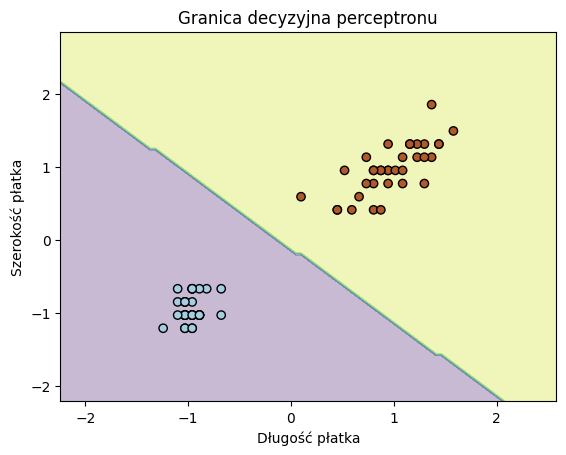

In [4]:
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    Z = p.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=plt.cm.Paired)
    plt.xlabel("Długość płatka")
    plt.ylabel("Szerokość płatka")
    plt.title("Granica decyzyjna perceptronu")
    plt.show()

plot_decision_boundary(X_train, y_train, p)
